# Stage 2 - Quantum encoding

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import os
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# ---- Model parameters, matching Stage 1 exactly ----
p0, rho, z_max = 0.25, 0.027, 3.0

def pd_given_z(z, p0=p0, rho=rho):
    """Classical GCI/Vasicek conditional default probability (from Stage 1)."""
    numerator = norm.ppf(p0) - np.sqrt(rho) * z
    denominator = np.sqrt(1 - rho)
    return norm.cdf(numerator / denominator)

def theta_exact(z):
    """The exact (nonlinear) rotation angle that reproduces PD(z) with zero error."""
    return np.arcsin(np.sqrt(pd_given_z(z)))

# ---- Fit a straight line theta(z) ~ alpha*z + beta via least squares ----
z_fit = np.linspace(-z_max, z_max, 400)
theta_fit_targets = theta_exact(z_fit)

alpha, beta = np.polyfit(z_fit, theta_fit_targets, 1)

print(f"Fitted slope   alpha = {alpha:.6f}")
print(f"Fitted offset  beta  = {beta:.6f}")
print(f"\nApproximation:  PD(z)  ~=  sin^2({alpha:.4f} * z + {beta:.4f})")

Fitted slope   alpha = -0.060489
Fitted offset  beta  = 0.524048

Approximation:  PD(z)  ~=  sin^2(-0.0605 * z + 0.5240)


In [3]:
z_test = np.linspace(-z_max, z_max, 400)
pd_true = pd_given_z(z_test)
pd_approx = np.sin(alpha * z_test + beta) ** 2
abs_error = np.abs(pd_approx - pd_true)

print(f"Max absolute error  : {abs_error.max():.5f}  ({abs_error.max()*100:.3f} percentage points)")
print(f"Mean absolute error : {abs_error.mean():.5f}  ({abs_error.mean()*100:.3f} percentage points)")

Max absolute error  : 0.00653  (0.653 percentage points)
Mean absolute error : 0.00248  (0.248 percentage points)


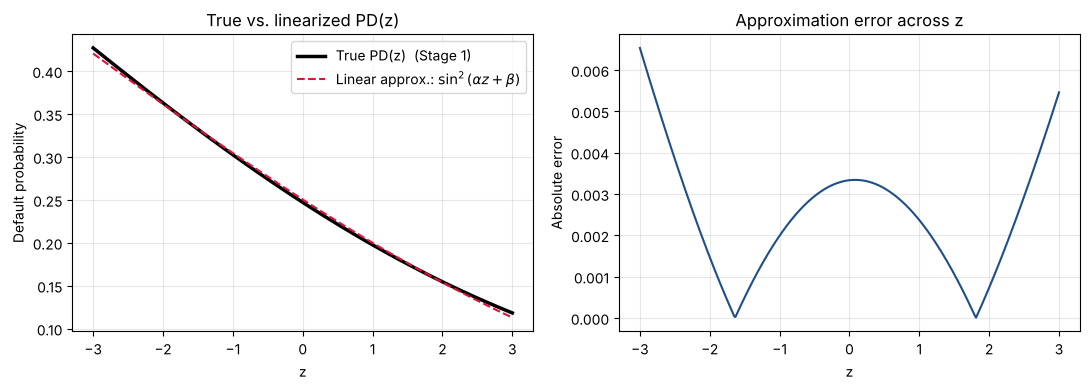

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(z_test, pd_true, color='black', linewidth=2.5, label='True PD(z)  (Stage 1)')
axes[0].plot(z_test, pd_approx, color='crimson', linewidth=1.5, linestyle='--',
             label=r'Linear approx.: $\sin^2(\alpha z + \beta)$')
axes[0].set_xlabel('z'); axes[0].set_ylabel('Default probability')
axes[0].set_title('True vs. linearized PD(z)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(z_test, abs_error, color='#1f4e8c')
axes[1].set_xlabel('z'); axes[1].set_ylabel('Absolute error')
axes[1].set_title('Approximation error across z')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/stage02_quantum_encoding_fit_validation.png', dpi=150)
plt.show()

In [5]:
def discretize_z(n_qubits, z_max=z_max):
    """Same discretization as Stage 1: maps basis index b -> grid point z(b)."""
    n_bins = 2 ** n_qubits
    b = np.arange(n_bins)
    z_grid = -z_max + (2 * z_max) * b / (n_bins - 1)
    return z_grid

def register_adapted_params(n_qubits, alpha=alpha, beta=beta, z_max=z_max):
    """Fold Stage 1's affine grid mapping into alpha, beta -> alpha_tilde, beta_tilde
    (matches the base paper's Eq. 4).
    """
    n_bins = 2 ** n_qubits
    slope = (2 * z_max) / (n_bins - 1)      # from z(b) = -z_max + slope * b
    alpha_tilde = alpha * slope
    beta_tilde = beta - alpha * z_max
    return alpha_tilde, beta_tilde

results = {}
for n_qubits in (2, 3):
    a_tilde, b_tilde = register_adapted_params(n_qubits)
    results[n_qubits] = (a_tilde, b_tilde)
    print(f"--- {n_qubits}-qubit z-register ---")
    print(f"  alpha_tilde = {a_tilde:.6f}")
    print(f"  beta_tilde  = {b_tilde:.6f}")

    # sanity check: alpha_tilde*b + beta_tilde must equal alpha*z(b) + beta for every b
    z_grid = discretize_z(n_qubits)
    lhs = a_tilde * np.arange(2 ** n_qubits) + b_tilde
    rhs = alpha * z_grid + beta
    print(f"  max mismatch vs. alpha*z(b)+beta : {np.max(np.abs(lhs - rhs)):.2e}\n")

--- 2-qubit z-register ---
  alpha_tilde = -0.120979
  beta_tilde  = 0.705516
  max mismatch vs. alpha*z(b)+beta : 0.00e+00

--- 3-qubit z-register ---
  alpha_tilde = -0.051848
  beta_tilde  = 0.705516
  max mismatch vs. alpha*z(b)+beta : 5.55e-17



In [6]:
# ---- Minimal NumPy statevector simulator: single-qubit and controlled single-qubit gates ----

def Ry(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -s], [s, c]])

def apply_single_qubit_gate(state, gate, qubit, n_total):
    """Apply a 2x2 gate to `qubit` within an n_total-qubit statevector.
    Bit convention: qubit k is bit position k of the basis-state index (qubit 0 = LSB).
    """
    new_state = state.copy()
    for idx in range(2 ** n_total):
        if ((idx >> qubit) & 1) == 0:
            partner = idx | (1 << qubit)
            a0, a1 = state[idx], state[partner]
            new_state[idx] = gate[0, 0] * a0 + gate[0, 1] * a1
            new_state[partner] = gate[1, 0] * a0 + gate[1, 1] * a1
    return new_state

def apply_controlled_gate(state, gate, control, target, n_total):
    """Apply `gate` to `target`, only where `control` bit == 1."""
    new_state = state.copy()
    for idx in range(2 ** n_total):
        if ((idx >> control) & 1) == 1 and ((idx >> target) & 1) == 0:
            partner = idx | (1 << target)
            a0, a1 = state[idx], state[partner]
            new_state[idx] = gate[0, 0] * a0 + gate[0, 1] * a1
            new_state[partner] = gate[1, 0] * a0 + gate[1, 1] * a1
    return new_state

def simulate_asset_qubit(n_qubits, register_value_b, alpha_tilde, beta_tilde):
    """Register qubits occupy bit positions 0..n_qubits-1 (fixed to `register_value_b`);
    the asset qubit occupies bit position n_qubits.
    Applies: one unconditional Ry(2*beta_tilde), then n controlled-Ry(2*alpha_tilde*2^k) gates.
    Returns P(asset qubit = 1).
    """
    n_total = n_qubits + 1
    asset_qubit = n_qubits

    # initial state: register in basis state |b>, asset qubit in |0>
    state = np.zeros(2 ** n_total)
    state[register_value_b] = 1.0   # asset bit is the top bit, and it's 0, so index = b directly

    # unconditional offset rotation
    state = apply_single_qubit_gate(state, Ry(2 * beta_tilde), asset_qubit, n_total)

    # controlled rotations, one per register qubit, binary-weighted angle
    for k in range(n_qubits):
        angle_k = 2 * alpha_tilde * (2 ** k)
        state = apply_controlled_gate(state, Ry(angle_k), control=k, target=asset_qubit, n_total=n_total)

    # P(asset qubit = 1) = sum of |amplitude|^2 over all basis states with that bit set
    p_asset_1 = sum(abs(state[idx]) ** 2 for idx in range(2 ** n_total) if ((idx >> asset_qubit) & 1) == 1)
    return p_asset_1

# ---- Run the check across every basis state, for both register sizes ----
for n_qubits in (2, 3):
    a_tilde, b_tilde = results[n_qubits]
    z_grid = discretize_z(n_qubits)
    print(f"=== {n_qubits}-qubit register: verifying the {n_qubits+1}-gate encoding trick ===")
    print(f"{'b':>3} | {'z(b)':>7} | {'PD_true(z)':>10} | {'sin^2(a~b+b~)':>14} | {'circuit sim.':>12} | {'match?':>7}")
    print("-" * 72)
    for b in range(2 ** n_qubits):
        pd_true = pd_given_z(z_grid[b])
        formula_pred = np.sin(a_tilde * b + b_tilde) ** 2
        circuit_pred = simulate_asset_qubit(n_qubits, b, a_tilde, b_tilde)
        match = np.isclose(formula_pred, circuit_pred, atol=1e-10)
        print(f"{b:3d} | {z_grid[b]:7.3f} | {pd_true:10.4f} | {formula_pred:14.4f} | {circuit_pred:12.4f} | {str(match):>7}")
    print()

=== 2-qubit register: verifying the 3-gate encoding trick ===
  b |    z(b) | PD_true(z) |  sin^2(a~b+b~) | circuit sim. |  match?
------------------------------------------------------------------------
  0 |  -3.000 |     0.4270 |         0.4205 |       0.4205 |    True
  1 |  -1.000 |     0.3025 |         0.3045 |       0.3045 |    True
  2 |   1.000 |     0.1976 |         0.1999 |       0.1999 |    True
  3 |   3.000 |     0.1183 |         0.1128 |       0.1128 |    True

=== 3-qubit register: verifying the 4-gate encoding trick ===
  b |    z(b) | PD_true(z) |  sin^2(a~b+b~) | circuit sim. |  match?
------------------------------------------------------------------------
  0 |  -3.000 |     0.4270 |         0.4205 |       0.4205 |    True
  1 |  -2.143 |     0.3719 |         0.3698 |       0.3698 |    True
  2 |  -1.286 |     0.3193 |         0.3205 |       0.3205 |    True
  3 |  -0.429 |     0.2701 |         0.2732 |       0.2732 |    True
  4 |   0.429 |     0.2251 |         0.

In [7]:
import json

encoding_params = {
    "continuous_fit": {"alpha": float(alpha), "beta": float(beta), "z_max": z_max,
                        "max_abs_error": float(abs_error.max()),
                        "mean_abs_error": float(abs_error.mean())},
    "register_adapted": {
        "2_qubit": {"alpha_tilde": float(results[2][0]), "beta_tilde": float(results[2][1])},
        "3_qubit": {"alpha_tilde": float(results[3][0]), "beta_tilde": float(results[3][1])},
    },
}

with open("results/quantum_encoding_params.json", "w") as f:
    json.dump(encoding_params, f, indent=2)

print("Saved -> results/quantum_encoding_params.json")
print(json.dumps(encoding_params, indent=2))

Saved -> results/quantum_encoding_params.json
{
  "continuous_fit": {
    "alpha": -0.06048938346154498,
    "beta": 0.524047936793275,
    "z_max": 3.0,
    "max_abs_error": 0.006533327778504183,
    "mean_abs_error": 0.0024815404446668827
  },
  "register_adapted": {
    "2_qubit": {
      "alpha_tilde": -0.12097876692308995,
      "beta_tilde": 0.7055160871779099
    },
    "3_qubit": {
      "alpha_tilde": -0.05184804296703855,
      "beta_tilde": 0.7055160871779099
    }
  }
}
